**Fourier Feature Network using DeepXDE module**

In [1]:
import os
os.environ["DDE_BACKEND"] = "tensorflow.compat.v1"

import deepxde as dde


Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.



Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.model_selection import train_test_split

from scipy.ndimage import gaussian_filter1d
import tensorflow as tf


Data loading

In [3]:
datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton_multinoise.h5", 'r')

data_I_noisy_3 = np.array(np.array(datastore["I_large"]))

data_c_3 = np.array(np.array(datastore["c_large"]))
data_h_3 = np.array(np.array(datastore["h_large"]))
keys = list(datastore.keys())

# data_p_3 = np.array(np.array(datastore["parameters_large: J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts"]))

t = np.linspace(0, 1, 601).reshape(601, 1)
datastore.close()

Train-test split

In [4]:
train_label_3, test_label_3 = train_test_split(range(len(data_I_noisy_3)), test_size=0.5, random_state=42)

X_train = data_I_noisy_3[train_label_3,:].astype(np.float32)
X_test = data_I_noisy_3[test_label_3,:].astype(np.float32)

y_train_c = data_c_3[train_label_3,:].astype(np.float32)
y_test_c = data_c_3[test_label_3,:].astype(np.float32)

y_train_h = data_h_3[train_label_3,:].astype(np.float32)
y_test_h = data_h_3[test_label_3,:].astype(np.float32)

del data_I_noisy_3, data_c_3, data_h_3

In [5]:
def custom_loss(y_true, y_pred):
   
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    

    d1 = y_pred[:, 1:] - y_pred[:, :-1]
    
    return mse + 1.6 * tf.reduce_mean(tf.square(d1)) 

In [6]:
data_c = dde.data.dataset.DataSet(
    X_train=X_train, y_train=y_train_c, X_test=X_test, y_test=y_test_c
)

m = 601
dim_x = 1

net_c = dde.nn.MsFFN(
    [m, 300, 200, 200, m],
    "relu",
    "Glorot normal",
    sigmas = [0.5, 1, 2]
)

model_c = dde.Model(data_c, net_c)
model_c.compile("adam", lr=1e-3, loss=custom_loss, metrics=["l2 relative error"])
# losshistory_c, train_state_c = model_c.train(iterations=1000, display_every=100)
path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/ffn_c/model_c_noisy_3_ffn-1000.ckpt'
model_c.restore(path)

Compiling model...
Building Multiscale Fourier Feature Network...

'compile' took 1.201549 s

INFO:tensorflow:Restoring parameters from C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/ffn_c/model_c_noisy_3_ffn-1000.ckpt


In [7]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/ffn_c/model_c_noisy_3_ffn"
# model_c.save(path)

In [8]:
# def compute_parameters(layers):
#     params = 0
#     for i in range(len(layers) - 1):
#         params += layers[i] * layers[i + 1]  # Weights
#         params += layers[i + 1]             # Biases
#     return params

# branch_layers = [m, 600, 400, 400, m]

# branch_params = compute_parameters(branch_layers)
# total_params = branch_params
# print(f"Total trainable parameters: {total_params}")


In [9]:
data_h = dde.data.dataset.DataSet(
    X_train=X_train, y_train=y_train_h, X_test=X_test, y_test=y_test_h
)

net_h = dde.nn.MsFFN(
    [m, 300, 200, 200, m],
    "relu",
    "Glorot normal",
    sigmas = [0.5, 1, 2]
)

model_h = dde.Model(data_h, net_h)
model_h.compile("adam", lr=1e-3, loss=custom_loss, metrics=["l2 relative error"])
# losshistory_h, train_state_h = model_h.train(iterations=1000, display_every=100)
path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/ffn_h/model_h_noisy_3_ffn2-1000.ckpt'
model_h.restore(path)

Compiling model...
Building Multiscale Fourier Feature Network...
'compile' took 0.456981 s

INFO:tensorflow:Restoring parameters from C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/ffn_h/model_h_noisy_3_ffn2-1000.ckpt


In [10]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/ffn_c/model_h_noisy_3_ffn2"
# model_h.save(path)

Average Relative RMSE for model_c on noisy data with 3 noise levels: 0.03831224516034126
Average Relative RMSE for model_h on noisy data with 3 noise levels: 0.032921209931373596


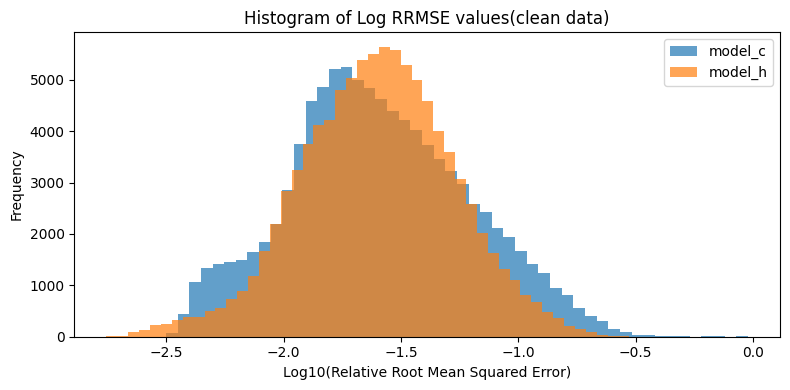

In [11]:
# Use trained model to make predictions
predictions_c = model_c.predict(X_test)
# predictions_c = predictions_c.astype(np.float32)
predictions_h = model_h.predict(X_test)
# predictions_h = predictions_h.astype(np.float32)

datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton_multinoise.h5", 'a')
with datastore as hf:
    if "predictions_c_ffn" in hf:
        del hf["predictions_c_ffn"]
    if "predictions_h_ffn" in hf:
        del hf["predictions_h_ffn"]
    hf.create_dataset("predictions_c_ffn", data=predictions_c, compression="gzip")
    hf.create_dataset("predictions_h_ffn", data=predictions_h, compression="gzip")
    
datastore.close()
# Compute Relative Mean Squared Error (RMSE) for model_c
rrmse_c = np.sqrt(np.sum((predictions_c - y_test_c) ** 2, axis=1) / np.sum((y_test_c ** 2), axis=1))
rrmse_h = np.sqrt(np.sum((predictions_h - y_test_h) ** 2, axis=1) / np.sum((y_test_h ** 2), axis=1))

print(f"Average Relative RMSE for model_c on noisy data with 3 noise levels: {np.mean(rrmse_c)}")
print(f"Average Relative RMSE for model_h on noisy data with 3 noise levels: {np.mean(rrmse_h)}")

# Log-scale histogram
plt.figure(figsize=(8, 4))
plt.hist(np.log10(rrmse_c), bins=50, alpha=0.7, label='model_c')
plt.hist(np.log10(rrmse_h), bins=50, alpha=0.7, label='model_h')
plt.xlabel('Log10(Relative Root Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RRMSE values(clean data)')
plt.legend()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/histograms/hist_FFN_clean_synthetic.png", bbox_inches="tight", pad_inches=0.1)
plt.tight_layout()
plt.show()




9403


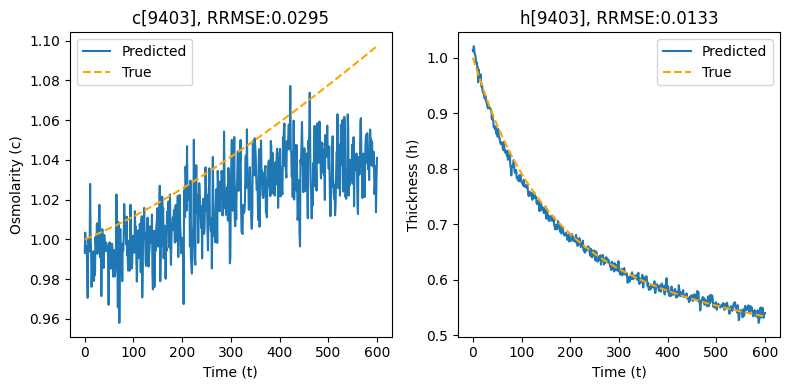

In [12]:
n = np.random.randint(0, len(X_test))

print(n)

pred_c_clean = model_c.predict(X_test[n].reshape(1, -1))
pred_h_clean = model_h.predict(X_test[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(8, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c_clean.T)
axs[0].plot(y_test_c[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title(f'c[{n}], RRMSE:{rrmse_c[n]:.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h_clean.T)
axs[1].plot(y_test_h[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title(f'h[{n}], RRMSE:{rrmse_h[n]:.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

In [13]:
datastore_glob = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/PDE_1d_glob_new_center_filtered.jld2", 'r')
data_I_glob = np.array(np.array(datastore_glob["filtered_data_I"]))

data_c_glob = np.array(np.array(datastore_glob["filtered_data_c"]))
data_h_glob = np.array(np.array(datastore_glob["filtered_data_h"]))

data_p_glob = np.array(np.array(datastore_glob["filtered_para"]))
data_ts_glob = data_p_glob[:,0].reshape(-1, 1)
data_h0_glob = data_p_glob[:,1].reshape(-1, 1)
data_f0_glob = data_p_glob[:,2].reshape(-1, 1)

datastore_glob.close()


Average Relative RMSE for model_c on global data: 0.17980676889419556
Average Relative RMSE for model_h on global data: 0.35754385590553284


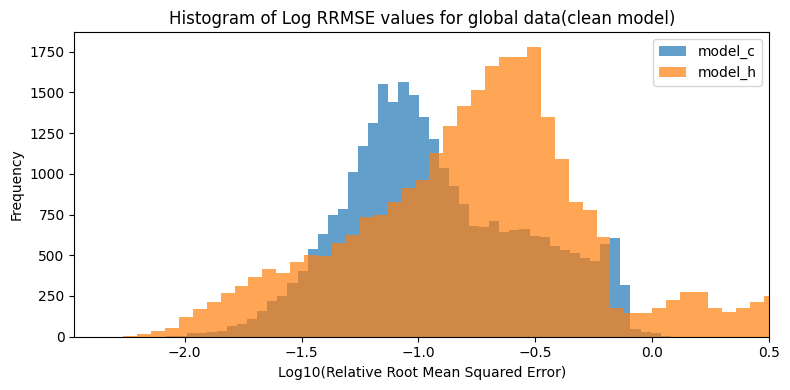

In [14]:
# Prepare the test data
X_test_glob = data_I_glob.astype(np.float32)
y_test_c_glob = data_c_glob.astype(np.float32)
y_test_h_glob = data_h_glob.astype(np.float32)

# Use trained models to make predictions
predictions_c_glob = model_c.predict(X_test_glob)
predictions_h_glob = model_h.predict(X_test_glob)

datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton_multinoise.h5", 'a')
with datastore as hf:
    if "predictions_c_ffn_glob" in hf:
        del hf["predictions_c_ffn_glob"]
    if "predictions_h_ffn_glob" in hf:
        del hf["predictions_h_ffn_glob"]
    hf.create_dataset("predictions_c_ffn_glob", data=predictions_c_glob, compression="gzip")
    hf.create_dataset("predictions_h_ffn_glob", data=predictions_h_glob, compression="gzip")
    
datastore.close()

# Compute Relative Mean Squared Error (RMSE) for model_c
rrmse_c_glob = np.sqrt(np.sum((predictions_c_glob - y_test_c_glob) ** 2, axis=1) / np.sum(y_test_c_glob ** 2, axis=1))
rrmse_h_glob = np.sqrt(np.sum((predictions_h_glob - y_test_h_glob) ** 2, axis=1) / np.sum(y_test_h_glob ** 2, axis=1))

print(f"Average Relative RMSE for model_c on global data: {np.mean(rrmse_c_glob)}")
print(f"Average Relative RMSE for model_h on global data: {np.mean(rrmse_h_glob)}")

# Log-scale histogram
plt.figure(figsize=(8,4))
plt.hist(np.log10(rrmse_c_glob), bins=50, alpha=0.7, label='model_c')
plt.hist(np.log10(rrmse_h_glob), bins=50, alpha=0.7, label='model_h')
plt.xlabel('Log10(Relative Root Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RRMSE values for global data(clean model)')
plt.legend()
plt.xlim(left=None, right=0.5)  # Set the x-axis limit to not go beyond 0.5
# plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/histograms/hist_glob_clean.png", dpi=300)
plt.tight_layout()
plt.show()

# Testing the model on experimental data

In [15]:
exprimental_data_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional.txt"
exprimental_data_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional_2.h5"
exprimental_data_nondimensional_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_nondimensional_2.h5"

In [16]:
with h5py.File(exprimental_data_path_h5, 'r') as h5f:
    t = h5f['t'][:]
    I = h5f['I'][:]
    p = h5f['p'][:]
    
I_scaled = np.array([row / row[0] for row in I], dtype=object)

h5py.File(exprimental_data_path_h5, 'r').close

<bound method File.close of <HDF5 file "experimental_data_dimensional_2.h5" (mode r)>>

In [17]:
def scale_time_arrays(t):
    """
    Linearly scale each time array so that:
      - the first value becomes 0
      - the value equal to ts becomes 1

    Parameters:
    - t: list or array of 1D numpy arrays (ragged)
    - ts_array: 1D array of float, ts for each instance

    Returns:
    - t_scaled: list of scaled time arrays with same structure
    """
    t_scaled = []

    for i in range(len(t)):
        t_i = t[i]
        t0 = t_i[0]
        t_end = t_i[-1]  # Assuming ts is the last value in the array

        t_scaled_i = (t_i - t0) / (t_end - t0)
        t_scaled.append(t_scaled_i)

    return np.array(t_scaled, dtype=object)


In [18]:
with h5py.File(exprimental_data_path_h5, 'r') as h5f:
    t_group = h5f['t']
    # Structured array access for 'ts'
    ts_array = h5f['p']['ts']
    id_array = h5f['p']['id']

t_scaled = scale_time_arrays(t)
h5py.File(exprimental_data_path_h5, 'r').close()

In [19]:
from scipy.interpolate import PchipInterpolator

# Interpolate each row of t_scaled and I_scaled to length 601
n_points = 601
t_uniform = np.linspace(0, 1, n_points)

t_scaled_interp = []
I_scaled_interp = []

for t_row, I_row in zip(t_scaled, I_scaled):
    # Interpolators
    t_interp = t_uniform  # target x-axis
    I_interp_func = PchipInterpolator(t_row, I_row)
    I_interp = I_interp_func(t_interp)
    t_scaled_interp.append(t_interp)
    I_scaled_interp.append(I_interp)

t_scaled_interp = np.array(t_scaled_interp)
I_scaled_interp = np.array(I_scaled_interp)

In [20]:
datastore = h5py.File(exprimental_data_nondimensional_path_h5, 'r')
data_I_calculated = np.array(datastore["calculated_I"])
data_h_calculated = np.array(datastore["calculated_h"])
data_f_calculated = np.array(datastore["calculated_f"])

data_c_caluculated = np.array(datastore["calculated_c"])
data_p_experimental_nondimensional = np.array(datastore["nondimensional_p"])

datastore.close()  # Close the read-only handle


Experimental RMSE for model_c_clean: 0.2821867
Experimental RMSE for model_h_clean: 0.092234954


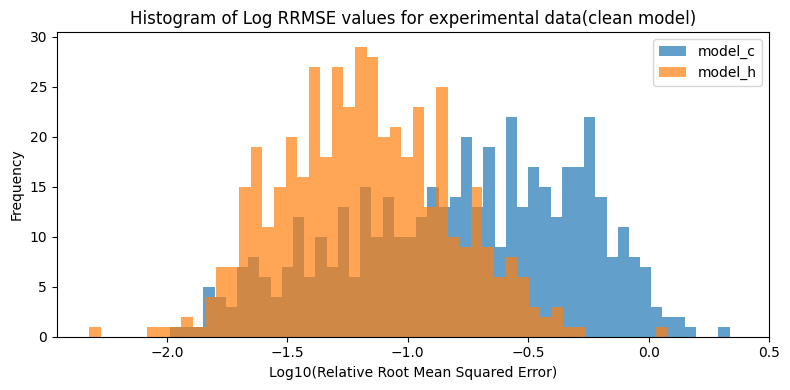

In [21]:
# Prepare the test data
X_test_expr = I_scaled_interp.astype(np.float32)
y_test_c_calculated = data_c_caluculated.astype(np.float32)
y_test_h_calculated = data_h_calculated.astype(np.float32)

# Use trained models to make predictions
predictions_c_calculated = model_c.predict(X_test_expr)
predictions_h_calculated = model_h.predict(X_test_expr)

datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton_multinoise.h5", 'a')
with datastore as hf:
    if "predictions_c_ffn_calculated" in hf:
        del hf["predictions_c_ffn_calculated"]
    if "predictions_h_ffn_calculated" in hf:
        del hf["predictions_h_ffn_calculated"]
    hf.create_dataset("predictions_c_ffn_calculated", data=predictions_c_calculated, compression="gzip")
    hf.create_dataset("predictions_h_ffn_calculated", data=predictions_h_calculated, compression="gzip")
    
datastore.close()

# Compute Relative Mean Squared Error (RMSE) for model_c
rrmse_c_calculated = np.sqrt(np.sum((predictions_c_calculated - y_test_c_calculated) ** 2, axis=1) / np.sum(y_test_c_calculated ** 2, axis=1))
rrmse_h_calculated = np.sqrt(np.sum((predictions_h_calculated - y_test_h_calculated) ** 2, axis=1) / np.sum(y_test_h_calculated ** 2, axis=1))

print("Experimental RMSE for model_c_clean:", np.mean(rrmse_c_calculated))
print("Experimental RMSE for model_h_clean:", np.mean(rrmse_h_calculated))

# Log-scale histogram
plt.figure(figsize=(8,4))
plt.hist(np.log10(rrmse_c_calculated), bins=50, alpha=0.7, label='model_c')
plt.hist(np.log10(rrmse_h_calculated), bins=50, alpha=0.7, label='model_h')
plt.xlabel('Log10(Relative Root Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RRMSE values for experimental data(clean model)')
plt.legend()
plt.xlim(left=None, right=0.5)  # Set the x-axis limit to not go beyond 0.5
plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/histograms/hist_expr_clean.png", dpi=300)
plt.show()


In [22]:
# Calculate predictions for f from predictions_c_calculated and f_0
# f_0 is the fifth entry of data_p_experimental_nondimensional (index 4)
f_0_experimental = data_p_experimental_nondimensional[:, 4]  # shape: (num_samples,)

# predictions_c_calculated shape: (num_samples, 601)
# We want to multiply each row of predictions_c_calculated by the corresponding f_0
predictions_f_calculated_clean = predictions_c_calculated * f_0_experimental[:, np.newaxis]

In [23]:
def calculate_I(h, f, phi, I_0=1.0):
    return I_0 * (1 - np.exp(-phi * h * f)) / (1 + f ** 2)

Experimental RMSE for I (reconstructed): 0.12161666742563565


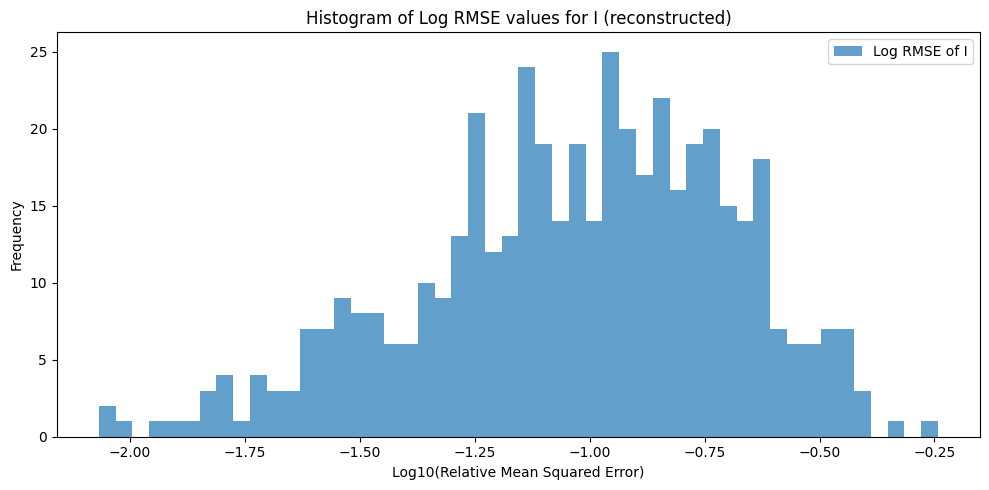

In [24]:
# Ensure phi is broadcastable to shape (num_samples, 601)
phi_expanded = data_p_experimental_nondimensional[:, 6][:, np.newaxis]  # shape: (num_samples, 1)

# Calculate I_pred using predictions_h_calculated and predictions_f_calculated
I_0_pred = 1/calculate_I(predictions_h_calculated[:,0].reshape(phi_expanded.shape), predictions_f_calculated_clean[:,0].reshape(phi_expanded.shape), phi=phi_expanded)
I_pred = calculate_I(predictions_h_calculated, predictions_f_calculated_clean, phi=phi_expanded, I_0=I_0_pred)

# Compute relative MSE for each sample
rel_mse_I = np.sqrt(np.sum((I_pred - data_I_calculated) ** 2, axis=1) / np.sum(data_I_calculated ** 2, axis=1))

print("Experimental RMSE for I (reconstructed):", np.mean(rel_mse_I))
# Plot histogram of log10(relative MSE)
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rel_mse_I), bins=50, alpha=0.7, label='Log RMSE of I')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for I (reconstructed)')
plt.legend()
plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/histograms/hist_I_reconstructed.png", dpi=300)
plt.show()

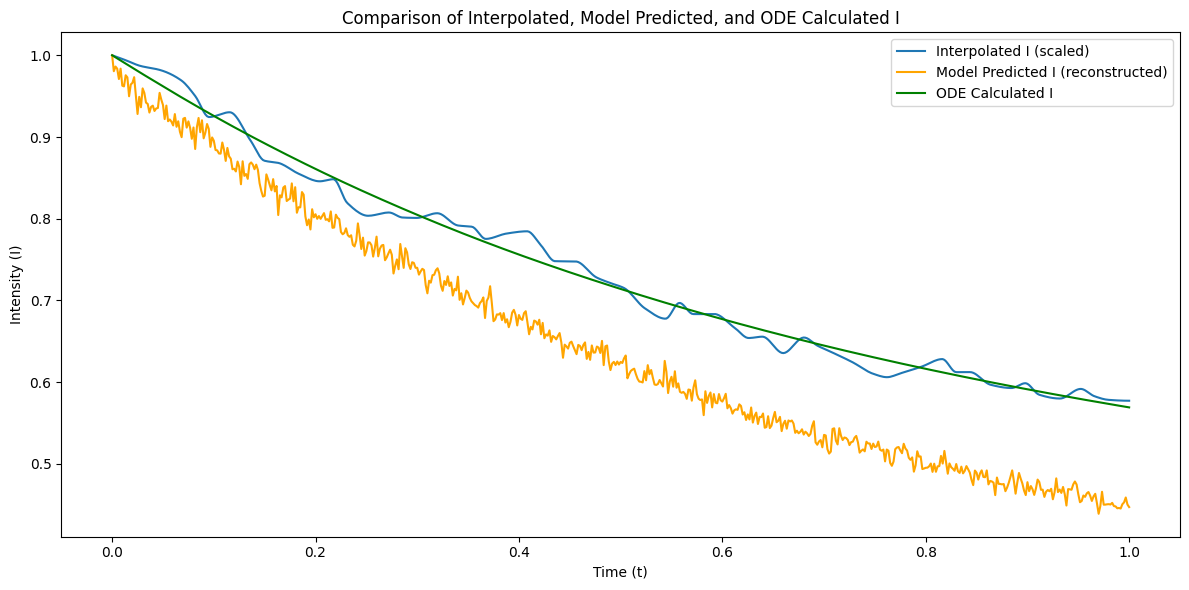

In [25]:
n = np.random.randint(0, len(I_scaled_interp))

plt.figure(figsize=(12, 6))
plt.plot(t_scaled_interp[n], I_scaled_interp[n], label='Interpolated I (scaled)')
plt.plot(t_scaled_interp[n], I_pred[n], color='orange', label='Model Predicted I (reconstructed)')
plt.plot(t_scaled_interp[n], data_I_calculated[n], color='green', label='ODE Calculated I')
plt.xlabel('Time (t)')
plt.ylabel('Intensity (I)')
plt.title('Comparison of Interpolated, Model Predicted, and ODE Calculated I')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# import os

# # Path where plots will be stored
# plot_dir_h = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/h_plots"
# plot_dir_c = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/c_plots"
# plot_dir_f = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/f_plots"
# plot_dir_I = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/I_plots"
# os.makedirs(plot_dir_h, exist_ok=True)  # Create the folder if it doesn't exist
# os.makedirs(plot_dir_c, exist_ok=True)  # Create the folder if it doesn't exist
# os.makedirs(plot_dir_I, exist_ok=True)  # Create the folder if it doesn't exist
# os.makedirs(plot_dir_f, exist_ok=True)  # Create the folder if it doesn't exist

# # Loop through all 467 samples
# for idx in range(467):
#     # Get data for this sample (already loaded in your variables)
#     id = id_array[idx]
#     t = t_scaled_interp[idx]
#     I_exp = I_scaled_interp[idx]
#     h_true = data_h_calculated[idx]
#     c_true = data_c_caluculated[idx]
#     f_true = data_f_calculated[idx]
    
#     I_pred_n = I_pred[idx]
#     h_pred = predictions_h_calculated[idx]
#     c_pred = predictions_c_calculated[idx]
#     f_pred = predictions_f_calculated[idx]
    
#     I_ode = data_I_calculated[idx]
    
#     fig1, ax1 = plt.subplots()
#     ax1.plot(t, I_exp, label='Experimental I (scaled)')
#     ax1.plot(t, I_pred_n, label='Model Predicted I (reconstructed)')
#     ax1.plot(t, I_ode, color='green', label='ODE Calculated I')
#     ax1.set_title(f'I for Sample {id}')
#     ax1.set_xlabel('Time Index')
#     ax1.set_ylabel('I')
#     ax1.legend()
#     fig1.tight_layout()
#     fig1.savefig(f"{plot_dir_I}/I_{id}.png")
#     plt.close(fig1)

#     fig2, ax2 = plt.subplots()
#     ax2.plot(t, h_true, label='ODE calculated h')
#     ax2.plot(t, h_pred, label='Model Predicted h')
#     ax2.set_title(f'h for Sample {id}')
#     ax2.set_xlabel('Time Index')
#     ax2.set_ylabel('h')
#     ax2.legend()
#     fig2.tight_layout()
#     fig2.savefig(f"{plot_dir_h}/h_{id}.png")
#     plt.close(fig2)
    
#     fig3, ax3 = plt.subplots()
#     ax3.plot(t, c_true, label='ODE calculated c')
#     ax3.plot(t, c_pred, label='Model Predicted c')
#     ax3.set_title(f'c for Sample {id}')
#     ax3.set_xlabel('Time Index')
#     ax3.set_ylabel('c')
#     ax3.legend()
#     fig3.tight_layout()
#     fig3.savefig(f"{plot_dir_c}/c_{id}.png")
#     plt.close(fig3)
    
#     fig4, ax4 = plt.subplots()
#     ax4.plot(t, f_true, label='ODE calculated f')
#     ax4.plot(t, f_pred, label='Model Predicted f')
#     ax4.set_title(f'f for Sample {id}')
#     ax4.set_xlabel('Time Index')
#     ax4.set_ylabel('f')
#     ax4.legend()
#     fig4.tight_layout()
#     fig4.savefig(f"{plot_dir_f}/f_{id}.png")
#     plt.close(fig4)
